# MNIST Handwritten Digit Classification
## End-to-End Machine Learning Pipeline

This notebook develops a complete multiclass Machine Learning pipeline for handwritten digit classification using the MNIST dataset.

The project is designed to:

- explore and understand the structure of MNIST;
- create stratified training, validation, and test subsets;
- normalize image pixels while preventing data leakage;
- train and tune three distinct Machine Learning models;
- evaluate Accuracy, weighted Precision, weighted Recall, weighted F1-score, confusion matrices, and computational cost;
- analyze common classification errors;
- investigate hidden-class and Out-of-Distribution (OOD) behavior;
- discuss model overconfidence;
- preprocess and classify handwritten digits created outside MNIST;
- generate the supporting project files required for reproducibility and GitHub documentation.

## 1. Project Overview

MNIST (Modified National Institute of Standards and Technology) is a benchmark dataset for handwritten digit recognition. Each observation represents a grayscale image of a handwritten digit from 0 to 9.

Each original image contains **28 × 28 pixels**. When flattened into a one-dimensional vector, each image contains:

\[
28 \times 28 = 784
\]

numerical features.

Three complementary classifiers are compared:

1. **K-Nearest Neighbors (KNN)** — instance-based and distance-driven learning;
2. **Random Forest** — nonlinear ensemble learning based on decision trees;
3. **Multilayer Perceptron (MLP)** — an artificial neural network that learns nonlinear relationships between pixels and classes.

Hyperparameters are selected with the validation set. The independent test set remains untouched until final model evaluation.

## 2. Objectives

The specific objectives are to:

- load and inspect MNIST;
- verify dataset dimensions, data types, classes, missing values, and pixel statistics;
- visualize one representative example from every digit class;
- analyze class balance;
- perform a stratified 70% / 10% / 20% train-validation-test split;
- normalize pixel intensities from `[0, 255]` to `[0.0, 1.0]`;
- tune at least two hyperparameters for each of three classifiers;
- compare final test performance and computational cost;
- generate a complete 10 × 10 confusion matrix for every final model;
- identify common confusion pairs and visualize representative errors;
- perform a hidden-class experiment and an OOD evaluation;
- analyze false certainty and overconfidence;
- preprocess and classify student-created handwritten images;
- automatically generate project documentation files after successful execution.

## 3. Environment Setup and Reproducibility

The project uses Python and Jupyter Notebook. Relative paths are used throughout the project so that the repository can be executed on a different computer without editing machine-specific directories.

A fixed random seed is used whenever an algorithm contains stochastic behavior. This improves reproducibility of splits and model training, although execution time can still vary between computers.

In [3]:
from pathlib import Path
from time import perf_counter
from importlib.metadata import version, PackageNotFoundError
import random
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from IPython.display import display, Markdown
from PIL import Image
import cv2
import tabulate

from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
)

warnings.filterwarnings("default")

RANDOM_STATE = 42
IMAGE_HEIGHT = 28
IMAGE_WIDTH = 28
NUM_CLASSES = 10
PIXEL_MAX_VALUE = 255.0

random.seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)

print(f"Random state: {RANDOM_STATE}")
print(f"Image dimensions: {IMAGE_HEIGHT} x {IMAGE_WIDTH}")
print(f"Number of classes: {NUM_CLASSES}")

Random state: 42
Image dimensions: 28 x 28
Number of classes: 10


### 3.1 Project Directory Structure

The following folders separate the raw custom images, generated figures, documentation, and analysis outputs.

In [4]:
PROJECT_ROOT = Path.cwd()

DATA_DIR = PROJECT_ROOT / "data"
CUSTOM_DIGITS_DIR = DATA_DIR / "custom_digits"

IMAGES_DIR = PROJECT_ROOT / "images"
DATASET_SAMPLES_DIR = IMAGES_DIR / "dataset_samples"
CONFUSION_MATRICES_DIR = IMAGES_DIR / "confusion_matrices"
MODEL_COMPARISON_DIR = IMAGES_DIR / "model_comparison"
OOD_ANALYSIS_DIR = IMAGES_DIR / "ood_analysis"
CUSTOM_PREDICTIONS_DIR = IMAGES_DIR / "custom_predictions"

DOCS_DIR = PROJECT_ROOT / "docs"

directories = [
    DATA_DIR,
    CUSTOM_DIGITS_DIR,
    IMAGES_DIR,
    DATASET_SAMPLES_DIR,
    CONFUSION_MATRICES_DIR,
    MODEL_COMPARISON_DIR,
    OOD_ANALYSIS_DIR,
    CUSTOM_PREDICTIONS_DIR,
    DOCS_DIR,
]

for directory in directories:
    directory.mkdir(parents=True, exist_ok=True)

print("Project directories created successfully.")
print(f"Project root: {PROJECT_ROOT}")

Project directories created successfully.
Project root: c:\Projects\SCTEC\mnist2


## 4. Dataset Loading

The dataset is loaded with Scikit-learn's `fetch_openml` function using the `mnist_784` representation. In this format, each 28 × 28 image is already represented as a vector containing 784 pixel-intensity features.

The target is converted to integer labels to simplify later indexing and reporting.

In [5]:
print("Loading the MNIST dataset...")

try:
    mnist = fetch_openml(
        "mnist_784",
        version=1,
        as_frame=False,
        parser="auto",
    )
except TypeError:
    # Compatibility fallback for older Scikit-learn versions.
    mnist = fetch_openml(
        "mnist_784",
        version=1,
        as_frame=False,
    )

X = mnist.data
y = mnist.target.astype(np.int64)

print("MNIST dataset loaded successfully.")
print(f"Feature matrix shape: {X.shape}")
print(f"Target vector shape: {y.shape}")
print(f"Feature data type: {X.dtype}")
print(f"Target data type: {y.dtype}")
print(f"Target classes: {np.unique(y)}")

Loading the MNIST dataset...
MNIST dataset loaded successfully.
Feature matrix shape: (70000, 784)
Target vector shape: (70000,)
Feature data type: int64
Target data type: int64
Target classes: [0 1 2 3 4 5 6 7 8 9]


## 5. Dataset Structure

Rows correspond to handwritten images and columns correspond to pixel features.

A valid MNIST representation should contain 70,000 observations, 784 features, and 10 target classes. The following checks verify the expected internal structure before modeling.

In [6]:
number_of_samples = X.shape[0]
number_of_features = X.shape[1]
expected_feature_count = IMAGE_HEIGHT * IMAGE_WIDTH

print(f"Number of samples: {number_of_samples:,}")
print(f"Number of features: {number_of_features}")
print(f"Expected flattened feature count: {expected_feature_count}")

assert number_of_features == expected_feature_count, (
    "Unexpected number of features for MNIST images."
)
assert len(np.unique(y)) == NUM_CLASSES, (
    "Unexpected number of target classes."
)

print("Dataset structure validation passed.")

Number of samples: 70,000
Number of features: 784
Expected flattened feature count: 784
Dataset structure validation passed.


## 6. Exploratory Data Analysis

The EDA verifies data integrity before training. This includes missing values, pixel range, basic pixel statistics, class counts, and class percentages.

In [7]:
has_missing_features = np.isnan(X).any()
has_missing_targets = pd.isna(y).any()

pixel_statistics_df = pd.DataFrame(
    {
        "Statistic": ["Minimum", "Maximum", "Mean", "Standard Deviation"],
        "Pixel Value": [
            float(np.min(X)),
            float(np.max(X)),
            float(np.mean(X)),
            float(np.std(X)),
        ],
    }
)

print(f"Missing values in features: {has_missing_features}")
print(f"Missing values in targets: {has_missing_targets}")
display(pixel_statistics_df)

Missing values in features: False
Missing values in targets: False


,Statistic,Pixel Value
0,Minimum,0.000000
1,Maximum,255.000000
2,Mean,33.385965
3,Standard Deviation,78.654374


### 6.1 Class Distribution

For each class, the absolute sample count and its percentage of the full dataset are calculated. A reasonably balanced class distribution is desirable because no digit should dominate the learning objective merely because it appears far more frequently than the others.

,digit,sample_count,percentage
0,0,6903,9.861429
1,1,7877,11.252857
2,2,6990,9.985714
3,3,7141,10.201429
4,4,6824,9.748571
5,5,6313,9.018571
6,6,6876,9.822857
7,7,7293,10.418571
8,8,6825,9.750000
9,9,6958,9.940000


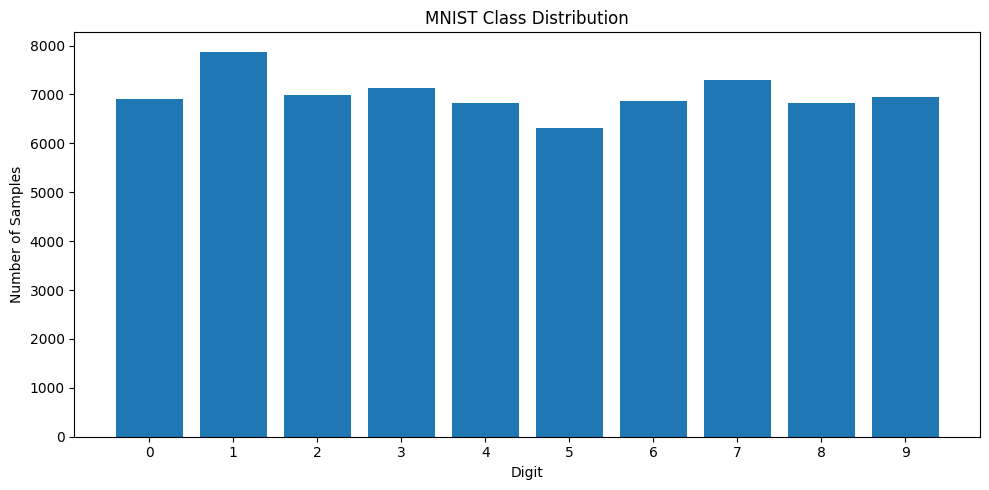

Largest-to-smallest class size ratio: 1.248


In [8]:
digits, class_counts = np.unique(y, return_counts=True)

class_distribution_df = pd.DataFrame(
    {
        "digit": digits,
        "sample_count": class_counts,
        "percentage": class_counts / len(y) * 100,
    }
)

display(class_distribution_df)

fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(class_distribution_df["digit"], class_distribution_df["sample_count"])
ax.set_title("MNIST Class Distribution")
ax.set_xlabel("Digit")
ax.set_ylabel("Number of Samples")
ax.set_xticks(range(NUM_CLASSES))
plt.tight_layout()

class_distribution_path = DATASET_SAMPLES_DIR / "class_distribution.png"
fig.savefig(class_distribution_path, dpi=150, bbox_inches="tight")
plt.show()

class_balance_ratio = (
    class_distribution_df["sample_count"].max()
    / class_distribution_df["sample_count"].min()
)
print(f"Largest-to-smallest class size ratio: {class_balance_ratio:.3f}")

In [9]:
balance_interpretation = f"""
### Class Balance Interpretation

The largest-to-smallest class size ratio is **{class_balance_ratio:.3f}**.

A ratio close to 1 indicates that the classes have similar sample sizes. MNIST is therefore sufficiently balanced for a direct multiclass comparison, although small differences in class support remain. Weighted metrics will later account for these support differences when Precision, Recall, and F1-score are summarized across classes.
"""
display(Markdown(balance_interpretation))


### Class Balance Interpretation

The largest-to-smallest class size ratio is **1.248**.

A ratio close to 1 indicates that the classes have similar sample sizes. MNIST is therefore sufficiently balanced for a direct multiclass comparison, although small differences in class support remain. Weighted metrics will later account for these support differences when Precision, Recall, and F1-score are summarized across classes.


## 7. Visualization of MNIST Digits

The following 2 × 5 grid displays one example from each class. The one-dimensional 784-feature vector is reshaped back into a 28 × 28 matrix only for visualization.

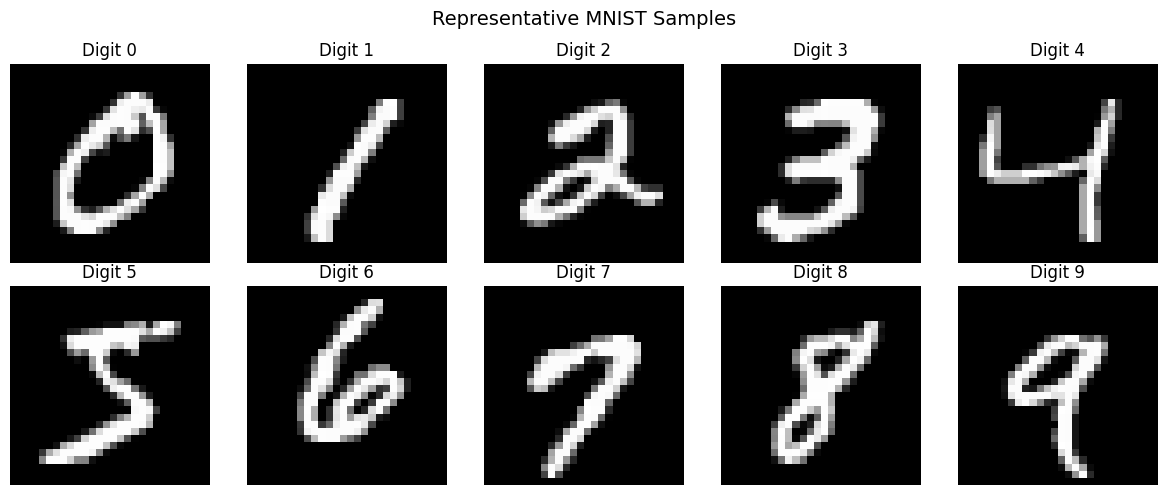

In [10]:
fig, axes = plt.subplots(2, 5, figsize=(12, 5))

for digit, ax in zip(range(NUM_CLASSES), axes.ravel()):
    sample_index = np.where(y == digit)[0][0]
    image = X[sample_index].reshape(IMAGE_HEIGHT, IMAGE_WIDTH)

    ax.imshow(image, cmap="gray")
    ax.set_title(f"Digit {digit}")
    ax.axis("off")

fig.suptitle("Representative MNIST Samples", fontsize=14)
plt.tight_layout()

sample_grid_path = DATASET_SAMPLES_DIR / "representative_mnist_digits.png"
fig.savefig(sample_grid_path, dpi=150, bbox_inches="tight")
plt.show()

### 7.1 Understanding Pixel Intensities and the 784-Dimensional Feature Space

A grayscale pixel is represented numerically. In the original MNIST representation, the expected intensity range is from 0 to 255.

- values close to 0 represent the background;
- larger values represent stronger foreground strokes;
- each 28 × 28 image contains 784 ordered pixel values.

The two-dimensional image:

\[
28 \times 28
\]

is flattened into the feature vector:

\[
x = [x_1, x_2, \ldots, x_{784}]
\]

so that conventional Machine Learning algorithms can receive the dataset as a matrix whose rows are samples and whose columns are numerical features.

## 8. Data Preprocessing

The preprocessing stage creates independent training, validation, and test datasets and normalizes all pixel values.

The target proportions are:

- **70% training**
- **10% validation**
- **20% testing**

Stratification is used to preserve approximately the same class distribution in every subset.

In [12]:
X_development_raw, X_test_raw, y_development, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=y,
)

X_train_raw, X_validation_raw, y_train, y_validation = train_test_split(
    X_development_raw,
    y_development,
    test_size=0.125,
    random_state=RANDOM_STATE,
    stratify=y_development,
)

print(f"Training samples: {len(y_train):,} ({len(y_train) / len(y) * 100:.1f}%)")
print(f"Validation samples: {len(y_validation):,} ({len(y_validation) / len(y) * 100:.1f}%)")
print(f"Test samples: {len(y_test):,} ({len(y_test) / len(y) * 100:.1f}%)")

Training samples: 49,000 (70.0%)
Validation samples: 7,000 (10.0%)
Test samples: 14,000 (20.0%)


### 8.1 Verification of Stratification

The following table compares the percentage of each digit in the complete dataset and in each split.

In [13]:
def class_percentage_table(labels, dataset_name):
    counts = pd.Series(labels).value_counts().sort_index()
    percentages = counts / counts.sum() * 100
    return percentages.rename(dataset_name)

split_distribution_df = pd.concat(
    [
        class_percentage_table(y, "Full Dataset"),
        class_percentage_table(y_train, "Training"),
        class_percentage_table(y_validation, "Validation"),
        class_percentage_table(y_test, "Test"),
    ],
    axis=1,
)

split_distribution_df.index.name = "Digit"
display(split_distribution_df.round(3))

,Full Dataset,Training,Validation,Test
Digit,,,,
0,9.861,9.861,9.857,9.864
1,11.253,11.253,11.257,11.250
2,9.986,9.986,9.986,9.986
3,10.201,10.202,10.200,10.200
4,9.749,9.749,9.743,9.750
5,9.019,9.018,9.014,9.021
6,9.823,9.822,9.829,9.821
7,10.419,10.418,10.414,10.421
8,9.750,9.749,9.757,9.750


### 8.2 Pixel Normalization

Pixel values are transformed from `[0, 255]` to `[0.0, 1.0]` using:

\[
x_{normalized} = \frac{x}{255}
\]

This transformation is especially important for:

- KNN, because distances depend directly on feature scale;
- MLP, because gradient-based optimization is numerically easier with well-scaled inputs;
- general numerical conditioning.

Because the divisor 255 is a fixed property of the pixel representation and is not estimated from the dataset, this normalization does not learn information from the test set.

In [15]:
X_train = X_train_raw.astype(np.float32) / PIXEL_MAX_VALUE
X_validation = X_validation_raw.astype(np.float32) / PIXEL_MAX_VALUE
X_test = X_test_raw.astype(np.float32) / PIXEL_MAX_VALUE
X_development = X_development_raw.astype(np.float32) / PIXEL_MAX_VALUE

print(f"Training pixel range: [{X_train.min():.3f}, {X_train.max():.3f}]")
print(f"Validation pixel range: [{X_validation.min():.3f}, {X_validation.max():.3f}]")
print(f"Test pixel range: [{X_test.min():.3f}, {X_test.max():.3f}]")

assert X_train.min() >= 0.0 and X_train.max() <= 1.0
assert X_validation.min() >= 0.0 and X_validation.max() <= 1.0
assert X_test.min() >= 0.0 and X_test.max() <= 1.0

print("Normalization validation passed.")

Training pixel range: [0.000, 1.000]
Validation pixel range: [0.000, 1.000]
Test pixel range: [0.000, 1.000]
Normalization validation passed.


### 8.3 Data Leakage Prevention

The test set is not used for:

- hyperparameter tuning;
- model selection;
- candidate-model comparison;
- development decisions.

Only the training and validation sets are used during model development. After the best hyperparameters are selected, the final version of each model is fitted on the complete 80% development dataset and evaluated once on the independent 20% test set.

This prevents information from the test set from influencing model design and provides a more reliable estimate of generalization performance.

## 9. Modeling Strategy

The three models represent different Machine Learning paradigms:

### K-Nearest Neighbors
KNN is an instance-based classifier. A new image is classified according to nearby labeled samples in feature space.

### Random Forest
Random Forest combines many decision trees. Each tree partitions the feature space differently, and the forest aggregates their predictions.

### Multilayer Perceptron
MLP is an artificial neural network. It learns nonlinear transformations of the 784 input pixels through one or more hidden layers.

For every model, at least two hyperparameters are investigated using validation accuracy. When two candidates produce the same validation accuracy, the faster candidate is preferred.

## 10. Model 1 — K-Nearest Neighbors

The investigated hyperparameters are:

- `n_neighbors`: number of neighboring samples considered during prediction;
- `weights`: whether all neighbors contribute equally (`uniform`) or closer neighbors receive larger influence (`distance`).

In [17]:
knn_candidates = [
    {"n_neighbors": 3, "weights": "uniform"},
    {"n_neighbors": 3, "weights": "distance"},
    {"n_neighbors": 5, "weights": "uniform"},
    {"n_neighbors": 5, "weights": "distance"},
]

knn_tuning_results = []

for params in knn_candidates:
    model = KNeighborsClassifier(
        n_neighbors=params["n_neighbors"],
        weights=params["weights"],
        n_jobs=-1,
    )

    start_time = perf_counter()
    model.fit(X_train, y_train)
    training_time = perf_counter() - start_time

    start_time = perf_counter()
    validation_predictions = model.predict(X_validation)
    validation_time = perf_counter() - start_time

    validation_accuracy = accuracy_score(y_validation, validation_predictions)

    knn_tuning_results.append(
        {
            **params,
            "validation_accuracy": validation_accuracy,
            "training_time_seconds": training_time,
            "validation_inference_seconds": validation_time,
        }
    )

knn_tuning_df = pd.DataFrame(knn_tuning_results).sort_values(
    by=["validation_accuracy", "training_time_seconds"],
    ascending=[False, True],
).reset_index(drop=True)

display(knn_tuning_df)

best_knn_params = {
    "n_neighbors": int(knn_tuning_df.iloc[0]["n_neighbors"]),
    "weights": knn_tuning_df.iloc[0]["weights"],
}

print(f"Selected KNN parameters: {best_knn_params}")

,n_neighbors,weights,validation_accuracy,training_time_seconds,validation_inference_seconds
0,3,distance,0.972286,0.025234,5.999506
1,3,uniform,0.971857,0.037773,6.113026
2,5,distance,0.971429,0.019464,5.812550
3,5,uniform,0.969429,0.022590,6.139945


Selected KNN parameters: {'n_neighbors': 3, 'weights': 'distance'}


In [18]:
display(Markdown(
    f"""
### KNN Hyperparameter Selection

The selected KNN configuration is:

- `n_neighbors = {best_knn_params['n_neighbors']}`
- `weights = "{best_knn_params['weights']}"`

This configuration achieved the highest validation accuracy among the tested KNN candidates. If two candidates achieved the same validation accuracy, the configuration with the lower measured training time was preferred.
"""
))


### KNN Hyperparameter Selection

The selected KNN configuration is:

- `n_neighbors = 3`
- `weights = "distance"`

This configuration achieved the highest validation accuracy among the tested KNN candidates. If two candidates achieved the same validation accuracy, the configuration with the lower measured training time was preferred.


## 11. Model 2 — Random Forest

The investigated hyperparameters are:

- `n_estimators`: number of decision trees in the ensemble;
- `max_depth`: maximum depth allowed for each tree.

More trees can improve stability but increase computational cost. Limiting tree depth can reduce complexity and overfitting.

In [19]:
random_forest_candidates = [
    {"n_estimators": 100, "max_depth": 20},
    {"n_estimators": 100, "max_depth": None},
    {"n_estimators": 200, "max_depth": 20},
    {"n_estimators": 200, "max_depth": None},
]

random_forest_tuning_results = []

for params in random_forest_candidates:
    model = RandomForestClassifier(
        n_estimators=params["n_estimators"],
        max_depth=params["max_depth"],
        random_state=RANDOM_STATE,
        n_jobs=-1,
    )

    start_time = perf_counter()
    model.fit(X_train, y_train)
    training_time = perf_counter() - start_time

    start_time = perf_counter()
    validation_predictions = model.predict(X_validation)
    validation_time = perf_counter() - start_time

    validation_accuracy = accuracy_score(y_validation, validation_predictions)

    random_forest_tuning_results.append(
        {
            **params,
            "validation_accuracy": validation_accuracy,
            "training_time_seconds": training_time,
            "validation_inference_seconds": validation_time,
        }
    )

random_forest_tuning_df = pd.DataFrame(random_forest_tuning_results).sort_values(
    by=["validation_accuracy", "training_time_seconds"],
    ascending=[False, True],
).reset_index(drop=True)

display(random_forest_tuning_df)

selected_depth = random_forest_tuning_df.iloc[0]["max_depth"]

best_random_forest_params = {
    "n_estimators": int(random_forest_tuning_df.iloc[0]["n_estimators"]),
    "max_depth": None if pd.isna(selected_depth) else int(selected_depth),
}

print(f"Selected Random Forest parameters: {best_random_forest_params}")

,n_estimators,max_depth,validation_accuracy,training_time_seconds,validation_inference_seconds
0,200,NaN,0.968000,16.507389,0.185830
1,200,20.0,0.966714,15.051654,0.191972
2,100,NaN,0.966143,8.496551,0.092970
3,100,20.0,0.965143,7.981752,0.121237


Selected Random Forest parameters: {'n_estimators': 200, 'max_depth': None}


In [21]:
display(Markdown(
    f"""
### Random Forest Hyperparameter Selection

The selected Random Forest configuration is:

- `n_estimators = {best_random_forest_params['n_estimators']}`
- `max_depth = {best_random_forest_params['max_depth']}`

The configuration was selected according to validation accuracy, with training time used as a secondary criterion in case of equivalent validation performance.
"""
))


### Random Forest Hyperparameter Selection

The selected Random Forest configuration is:

- `n_estimators = 200`
- `max_depth = None`

The configuration was selected according to validation accuracy, with training time used as a secondary criterion in case of equivalent validation performance.


## 12. Model 3 — Multilayer Perceptron

The investigated hyperparameters are:

- `hidden_layer_sizes`: architecture and number of neurons in the hidden layer(s);
- `learning_rate_init`: initial step size used by the optimizer.

The MLP uses early stopping so that training can terminate when the internal validation score stops improving.

In [22]:
mlp_candidates = [
    {"hidden_layer_sizes": (64,), "learning_rate_init": 0.001},
    {"hidden_layer_sizes": (64,), "learning_rate_init": 0.0005},
    {"hidden_layer_sizes": (128,), "learning_rate_init": 0.001},
    {"hidden_layer_sizes": (128,), "learning_rate_init": 0.0005},
]

mlp_tuning_results = []

for params in mlp_candidates:
    model = MLPClassifier(
        hidden_layer_sizes=params["hidden_layer_sizes"],
        learning_rate_init=params["learning_rate_init"],
        max_iter=40,
        early_stopping=True,
        n_iter_no_change=5,
        validation_fraction=0.1,
        random_state=RANDOM_STATE,
        verbose=False,
    )

    start_time = perf_counter()
    model.fit(X_train, y_train)
    training_time = perf_counter() - start_time

    start_time = perf_counter()
    validation_predictions = model.predict(X_validation)
    validation_time = perf_counter() - start_time

    validation_accuracy = accuracy_score(y_validation, validation_predictions)

    mlp_tuning_results.append(
        {
            **params,
            "validation_accuracy": validation_accuracy,
            "training_time_seconds": training_time,
            "validation_inference_seconds": validation_time,
            "epochs_completed": model.n_iter_,
        }
    )

mlp_tuning_df = pd.DataFrame(mlp_tuning_results).sort_values(
    by=["validation_accuracy", "training_time_seconds"],
    ascending=[False, True],
).reset_index(drop=True)

display(mlp_tuning_df)

best_mlp_params = {
    "hidden_layer_sizes": mlp_tuning_df.iloc[0]["hidden_layer_sizes"],
    "learning_rate_init": float(mlp_tuning_df.iloc[0]["learning_rate_init"]),
}

print(f"Selected MLP parameters: {best_mlp_params}")

,hidden_layer_sizes,learning_rate_init,validation_accuracy,training_time_seconds,validation_inference_seconds,epochs_completed
0,"(64,)",0.0010,0.974286,14.138723,0.012067,28
1,"(128,)",0.0005,0.974000,25.200120,0.014169,35
2,"(128,)",0.0010,0.972000,15.696480,0.014062,21
3,"(64,)",0.0005,0.969429,13.048373,0.010562,28


Selected MLP parameters: {'hidden_layer_sizes': (64,), 'learning_rate_init': 0.001}


In [23]:
display(Markdown(
    f"""
### MLP Hyperparameter Selection

The selected MLP configuration is:

- `hidden_layer_sizes = {best_mlp_params['hidden_layer_sizes']}`
- `learning_rate_init = {best_mlp_params['learning_rate_init']}`

The configuration was selected using external validation accuracy. Early stopping is used inside the training procedure to reduce unnecessary iterations and limit overfitting.
"""
))


### MLP Hyperparameter Selection

The selected MLP configuration is:

- `hidden_layer_sizes = (64,)`
- `learning_rate_init = 0.001`

The configuration was selected using external validation accuracy. Early stopping is used inside the training procedure to reduce unnecessary iterations and limit overfitting.


## 13. Final Training of the Three Models

After hyperparameter selection, each final model is trained on the complete **development dataset (80%)**, which combines the original training and validation information.

The independent test dataset remains untouched until the next section.

Training time and inference time are measured on the same notebook session so that computational cost can be compared relatively.

In [24]:
def build_model(model_name, params):
    if model_name == "KNN":
        return KNeighborsClassifier(
            n_neighbors=params["n_neighbors"],
            weights=params["weights"],
            n_jobs=-1,
        )

    if model_name == "Random Forest":
        return RandomForestClassifier(
            n_estimators=params["n_estimators"],
            max_depth=params["max_depth"],
            random_state=RANDOM_STATE,
            n_jobs=-1,
        )

    if model_name == "MLP":
        return MLPClassifier(
            hidden_layer_sizes=params["hidden_layer_sizes"],
            learning_rate_init=params["learning_rate_init"],
            max_iter=40,
            early_stopping=True,
            n_iter_no_change=5,
            validation_fraction=0.1,
            random_state=RANDOM_STATE,
            verbose=False,
        )

    raise ValueError(f"Unsupported model name: {model_name}")


selected_parameters = {
    "KNN": best_knn_params,
    "Random Forest": best_random_forest_params,
    "MLP": best_mlp_params,
}

final_models = {}
final_predictions = {}
final_training_times = {}
final_inference_times = {}

for model_name, params in selected_parameters.items():
    print(f"Training final {model_name} model...")

    model = build_model(model_name, params)

    start_time = perf_counter()
    model.fit(X_development, y_development)
    training_time = perf_counter() - start_time

    start_time = perf_counter()
    test_predictions = model.predict(X_test)
    inference_time = perf_counter() - start_time

    final_models[model_name] = model
    final_predictions[model_name] = test_predictions
    final_training_times[model_name] = training_time
    final_inference_times[model_name] = inference_time

    print(
        f"{model_name}: training={training_time:.3f}s, "
        f"test inference={inference_time:.3f}s"
    )

Training final KNN model...
KNN: training=0.042s, test inference=14.707s
Training final Random Forest model...
Random Forest: training=20.039s, test inference=0.394s
Training final MLP model...
MLP: training=19.136s, test inference=0.024s


## 14. Final Test Evaluation

For a multiclass problem, overall Accuracy alone is not sufficient. The following weighted metrics are calculated:

- **Accuracy** — fraction of all correctly classified images;
- **Weighted Precision** — class Precision weighted by class support;
- **Weighted Recall** — class Recall weighted by class support;
- **Weighted F1-score** — class F1-score weighted by class support.

For a generic class metric \(m_i\), the weighted average is:

\[
m_{weighted} =
\frac{\sum_i m_i \times support_i}
{\sum_i support_i}
\]

where `support` is the number of true samples belonging to each class.

In [25]:
evaluation_rows = []

for model_name, predictions in final_predictions.items():
    evaluation_rows.append(
        {
            "model": model_name,
            "accuracy": accuracy_score(y_test, predictions),
            "weighted_precision": precision_score(
                y_test, predictions, average="weighted", zero_division=0
            ),
            "weighted_recall": recall_score(
                y_test, predictions, average="weighted", zero_division=0
            ),
            "weighted_f1": f1_score(
                y_test, predictions, average="weighted", zero_division=0
            ),
            "training_time_seconds": final_training_times[model_name],
            "inference_time_seconds": final_inference_times[model_name],
        }
    )

model_comparison_df = pd.DataFrame(evaluation_rows).sort_values(
    by=["weighted_f1", "accuracy", "inference_time_seconds"],
    ascending=[False, False, True],
).reset_index(drop=True)

display(model_comparison_df)

,model,accuracy,weighted_precision,weighted_recall,weighted_f1,training_time_seconds,inference_time_seconds
0,KNN,0.973214,0.973408,0.973214,0.973185,0.042051,14.707066
1,MLP,0.973071,0.973105,0.973071,0.973047,19.135794,0.024450
2,Random Forest,0.968143,0.968142,0.968143,0.968122,20.038643,0.394340


## 15. Confusion Matrices

A complete 10 × 10 confusion matrix is generated for every final model.

Rows represent **actual digits** and columns represent **predicted digits**. Values outside the main diagonal are classification errors.

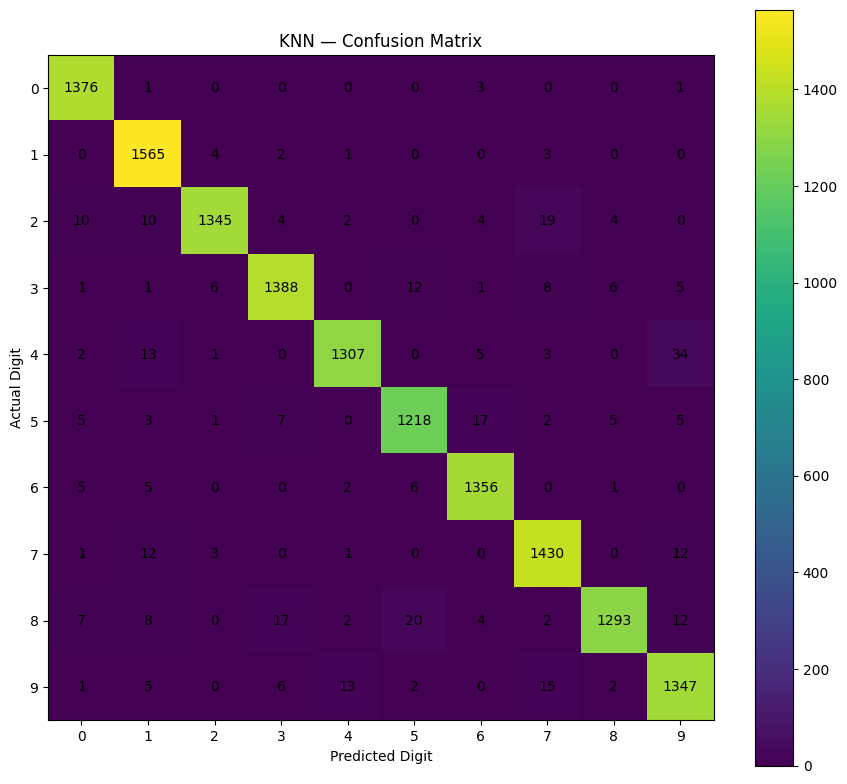

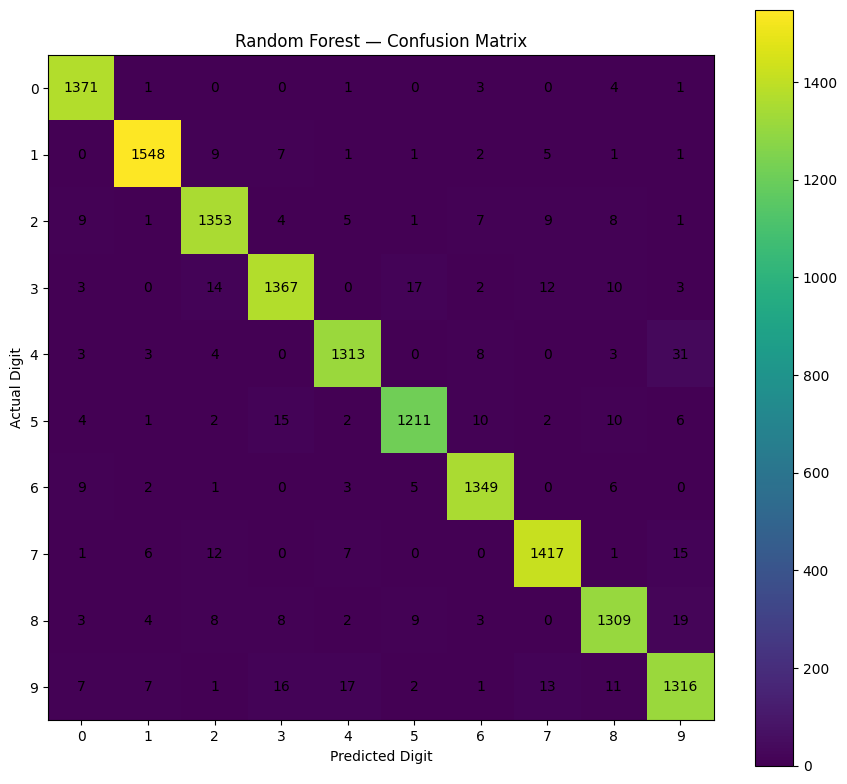

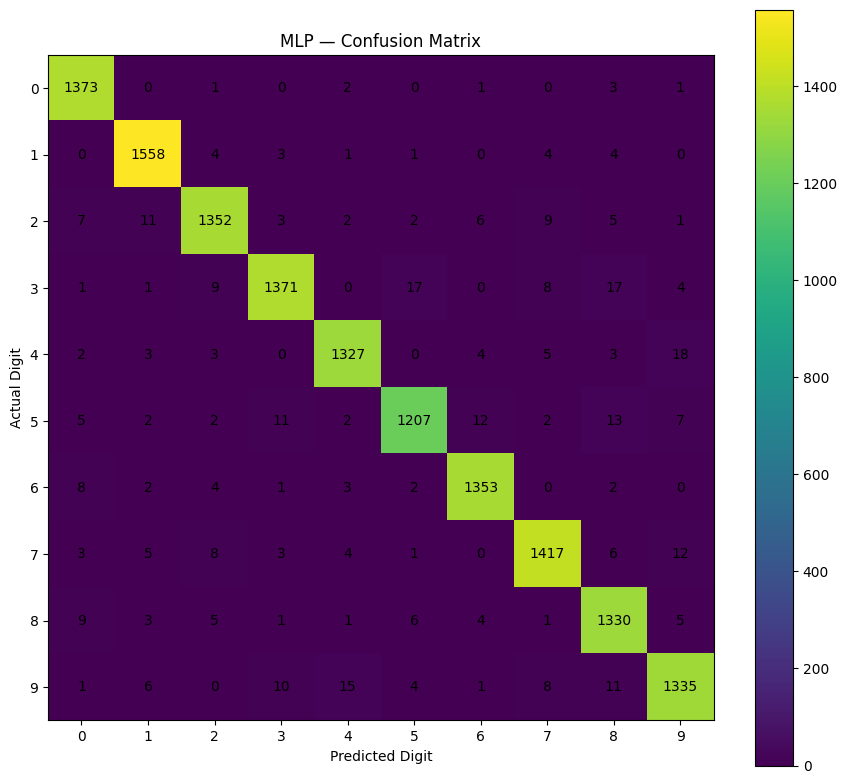

In [26]:
def plot_confusion_matrix_manual(y_true, y_pred, model_name, save_path):
    cm = confusion_matrix(y_true, y_pred, labels=np.arange(NUM_CLASSES))

    fig, ax = plt.subplots(figsize=(9, 8))
    image = ax.imshow(cm)
    fig.colorbar(image, ax=ax)

    ax.set_title(f"{model_name} — Confusion Matrix")
    ax.set_xlabel("Predicted Digit")
    ax.set_ylabel("Actual Digit")
    ax.set_xticks(np.arange(NUM_CLASSES))
    ax.set_yticks(np.arange(NUM_CLASSES))

    for row in range(NUM_CLASSES):
        for column in range(NUM_CLASSES):
            ax.text(
                column,
                row,
                f"{cm[row, column]}",
                ha="center",
                va="center",
            )

    plt.tight_layout()
    fig.savefig(save_path, dpi=150, bbox_inches="tight")
    plt.show()

    return cm


confusion_matrices = {}

for model_name, predictions in final_predictions.items():
    file_name = model_name.lower().replace(" ", "_") + "_confusion_matrix.png"
    save_path = CONFUSION_MATRICES_DIR / file_name

    confusion_matrices[model_name] = plot_confusion_matrix_manual(
        y_test,
        predictions,
        model_name,
        save_path,
    )

## 16. Per-Class Performance

The classification report shows Precision, Recall, F1-score, and support separately for each digit. This helps identify whether a model performs consistently across the ten classes.

In [27]:
classification_reports = {}

for model_name, predictions in final_predictions.items():
    report = classification_report(
        y_test,
        predictions,
        labels=np.arange(NUM_CLASSES),
        output_dict=True,
        zero_division=0,
    )

    report_df = pd.DataFrame(report).transpose()
    classification_reports[model_name] = report_df

    print(f"\\n{model_name} Classification Report")
    display(report_df)

\nKNN Classification Report


,precision,recall,f1-score,support
0,0.977273,0.996379,0.986734,1381.000000
1,0.964264,0.993651,0.978737,1575.000000
2,0.988971,0.962089,0.975344,1398.000000
3,0.974719,0.971989,0.973352,1428.000000
4,0.984187,0.957509,0.970665,1365.000000
5,0.968203,0.964371,0.966283,1263.000000
6,0.975540,0.986182,0.980832,1375.000000
7,0.964912,0.980123,0.972458,1459.000000
8,0.986270,0.947253,0.966368,1365.000000
9,0.951271,0.968368,0.959743,1391.000000


\nRandom Forest Classification Report


,precision,recall,f1-score,support
0,0.972340,0.992759,0.982444,1381.000000
1,0.984107,0.982857,0.983482,1575.000000
2,0.963675,0.967811,0.965739,1398.000000
3,0.964714,0.957283,0.960984,1428.000000
4,0.971873,0.961905,0.966863,1365.000000
5,0.971910,0.958828,0.965325,1263.000000
6,0.974007,0.981091,0.977536,1375.000000
7,0.971879,0.971213,0.971546,1459.000000
8,0.960382,0.958974,0.959677,1365.000000
9,0.944724,0.946082,0.945402,1391.000000


\nMLP Classification Report


,precision,recall,f1-score,support
0,0.974450,0.994207,0.984229,1381.000000
1,0.979258,0.989206,0.984207,1575.000000
2,0.974063,0.967096,0.970567,1398.000000
3,0.977192,0.960084,0.968562,1428.000000
4,0.977892,0.972161,0.975018,1365.000000
5,0.973387,0.955661,0.964443,1263.000000
6,0.979725,0.984000,0.981858,1375.000000
7,0.974553,0.971213,0.972880,1459.000000
8,0.954089,0.974359,0.964117,1365.000000
9,0.965293,0.959741,0.962509,1391.000000


## 17. Most Common Digit Confusions

The confusion matrix diagonal represents correct predictions. To identify the most important errors, the diagonal is removed and the remaining class pairs are ranked by error count.

In [28]:
def get_confusion_pairs(cm):
    rows = []

    for actual_digit in range(NUM_CLASSES):
        for predicted_digit in range(NUM_CLASSES):
            if actual_digit != predicted_digit and cm[actual_digit, predicted_digit] > 0:
                rows.append(
                    {
                        "actual_digit": actual_digit,
                        "predicted_digit": predicted_digit,
                        "error_count": int(cm[actual_digit, predicted_digit]),
                    }
                )

    return (
        pd.DataFrame(rows)
        .sort_values("error_count", ascending=False)
        .reset_index(drop=True)
    )


confusion_pairs = {}

for model_name, cm in confusion_matrices.items():
    pairs_df = get_confusion_pairs(cm)
    confusion_pairs[model_name] = pairs_df

    print(f"\\nTop confusion pairs — {model_name}")
    display(pairs_df.head(10))

\nTop confusion pairs — KNN


,actual_digit,predicted_digit,error_count
0,4,9,34
1,8,5,20
2,2,7,19
3,5,6,17
4,8,3,17
5,9,7,15
6,4,1,13
7,9,4,13
8,7,1,12
9,7,9,12


\nTop confusion pairs — Random Forest


,actual_digit,predicted_digit,error_count
0,4,9,31
1,8,9,19
2,9,4,17
3,3,5,17
4,9,3,16
5,7,9,15
6,5,3,15
7,3,2,14
8,9,7,13
9,7,2,12


\nTop confusion pairs — MLP


,actual_digit,predicted_digit,error_count
0,4,9,18
1,3,5,17
2,3,8,17
3,9,4,15
4,5,8,13
5,5,6,12
6,7,9,12
7,5,3,11
8,2,1,11
9,9,8,11


## 18. Consolidated Model Comparison

The comparison considers predictive quality and computational cost. The best model is selected primarily by weighted F1-score, then by Accuracy, and finally by inference time when necessary.

This avoids selecting a model only because of a single metric.

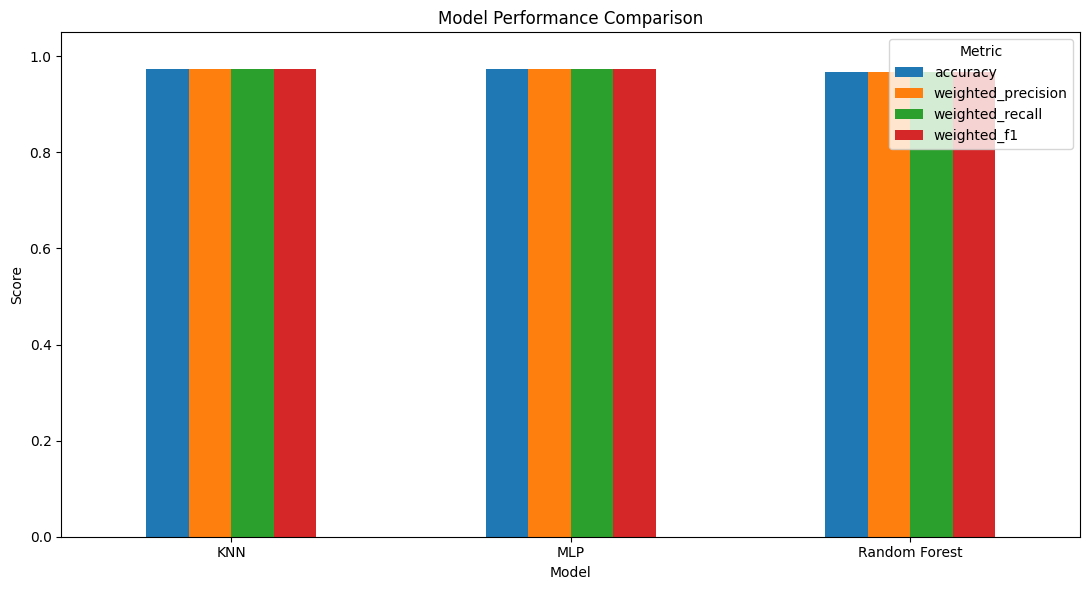

In [29]:
metrics_to_plot = [
    "accuracy",
    "weighted_precision",
    "weighted_recall",
    "weighted_f1",
]

plot_df = model_comparison_df.set_index("model")[metrics_to_plot]

ax = plot_df.plot(kind="bar", figsize=(11, 6))
ax.set_title("Model Performance Comparison")
ax.set_xlabel("Model")
ax.set_ylabel("Score")
ax.set_ylim(0, 1.05)
ax.legend(title="Metric")
plt.xticks(rotation=0)
plt.tight_layout()

performance_comparison_path = MODEL_COMPARISON_DIR / "model_performance_comparison.png"
plt.savefig(performance_comparison_path, dpi=150, bbox_inches="tight")
plt.show()

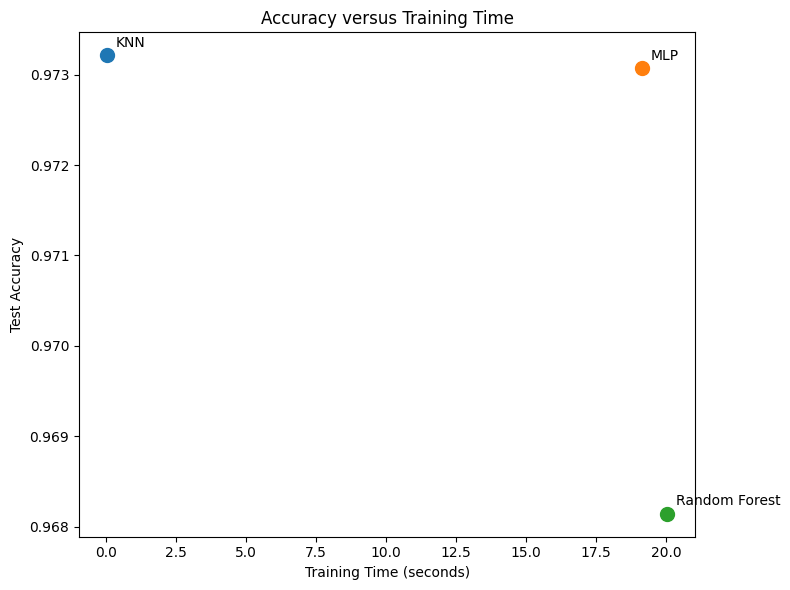

In [30]:
fig, ax = plt.subplots(figsize=(8, 6))

for _, row in model_comparison_df.iterrows():
    ax.scatter(
        row["training_time_seconds"],
        row["accuracy"],
        s=100,
        label=row["model"],
    )
    ax.annotate(
        row["model"],
        (row["training_time_seconds"], row["accuracy"]),
        xytext=(6, 6),
        textcoords="offset points",
    )

ax.set_title("Accuracy versus Training Time")
ax.set_xlabel("Training Time (seconds)")
ax.set_ylabel("Test Accuracy")
plt.tight_layout()

cost_comparison_path = MODEL_COMPARISON_DIR / "accuracy_vs_training_time.png"
fig.savefig(cost_comparison_path, dpi=150, bbox_inches="tight")
plt.show()

## 19. Best Model Selection

In [31]:
best_model_name = model_comparison_df.iloc[0]["model"]
best_model = final_models[best_model_name]
best_predictions = final_predictions[best_model_name]

best_row = model_comparison_df.iloc[0]

print(f"Selected best model: {best_model_name}")
display(model_comparison_df.head(1))

Selected best model: KNN


,model,accuracy,weighted_precision,weighted_recall,weighted_f1,training_time_seconds,inference_time_seconds
0,KNN,0.973214,0.973408,0.973214,0.973185,0.042051,14.707066


In [ ]:
top_confusions_best = confusion_pairs[best_model_name].head(3)

if len(top_confusions_best) > 0:
    confusion_text = ", ".join(
        [
            f"{int(row.actual_digit)}→{int(row.predicted_digit)} ({int(row.error_count)} errors)"
            for row in top_confusions_best.itertuples()
        ]
    )
else:
    confusion_text = "No off-diagonal errors were observed."

best_model_interpretation = f"""
## Best Model Selection
The selected final model is **{best_model_name}**.

Its independent test-set results are:

- **Accuracy:** {best_row['accuracy']:.4f}
- **Weighted Precision:** {best_row['weighted_precision']:.4f}
- **Weighted Recall:** {best_row['weighted_recall']:.4f}
- **Weighted F1-score:** {best_row['weighted_f1']:.4f}
- **Training time:** {best_row['training_time_seconds']:.3f} seconds
- **Inference time:** {best_row['inference_time_seconds']:.3f} seconds

The most frequent confusion pairs for this model are: **{confusion_text}**.

The selection uses weighted F1-score as the primary criterion because it combines Precision and Recall while respecting class support. Accuracy and inference time are used as secondary criteria. Computational time is hardware-dependent and should therefore be interpreted comparatively within this execution environment.
"""

display(Markdown(best_model_interpretation))

## 20. Representative Misclassified Images

A visual inspection of errors helps connect numerical metrics with the actual appearance of difficult handwritten samples.

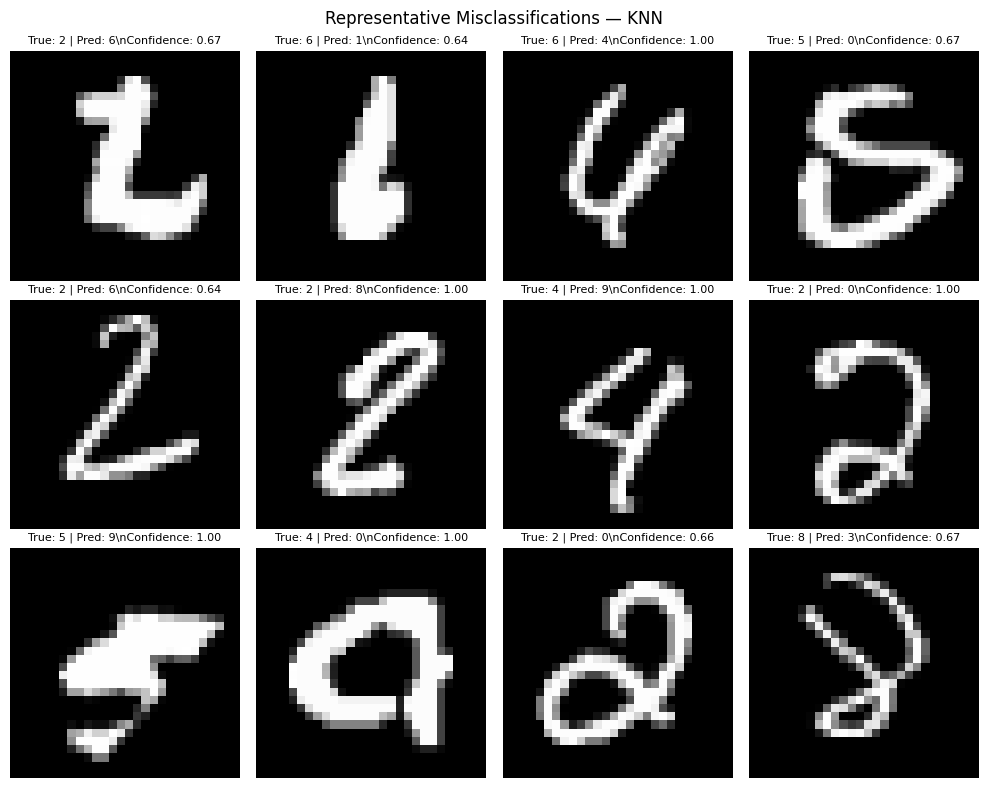

In [32]:
misclassified_indices = np.where(best_predictions != y_test)[0]

if len(misclassified_indices) == 0:
    print("No misclassified samples were found.")
else:
    number_to_show = min(12, len(misclassified_indices))
    selected_error_indices = misclassified_indices[:number_to_show]

    fig, axes = plt.subplots(3, 4, figsize=(10, 8))
    axes = axes.ravel()

    for ax in axes:
        ax.axis("off")

    probabilities = (
        best_model.predict_proba(X_test[selected_error_indices])
        if hasattr(best_model, "predict_proba")
        else None
    )

    for plot_index, sample_index in enumerate(selected_error_indices):
        image = X_test[sample_index].reshape(IMAGE_HEIGHT, IMAGE_WIDTH)
        true_label = y_test[sample_index]
        predicted_label = best_predictions[sample_index]

        title = f"True: {true_label} | Pred: {predicted_label}"

        if probabilities is not None:
            confidence = probabilities[plot_index].max()
            title += f"\\nConfidence: {confidence:.2f}"

        axes[plot_index].imshow(image, cmap="gray")
        axes[plot_index].set_title(title, fontsize=8)
        axes[plot_index].axis("off")

    fig.suptitle(f"Representative Misclassifications — {best_model_name}")
    plt.tight_layout()

    error_examples_path = MODEL_COMPARISON_DIR / "best_model_misclassifications.png"
    fig.savefig(error_examples_path, dpi=150, bbox_inches="tight")
    plt.show()